In [15]:
import pandas as pd
import numpy as np
import sklearn
import xgboost
import matplotlib
import seaborn
print("All libraries working!")
print(f"XGBoost version: {xgboost.__version__}")
print(f"Sklearn version: {sklearn.__version__}")

All libraries working!
XGBoost version: 3.2.0
Sklearn version: 1.8.0


# Assignment 5: Binary Classification - Bankruptcy Prediction
## 1. Problem Definition

In [16]:
# Section 1: Problem Definition
print("""
TARGET VARIABLE: Bankrupt?
POSITIVE CLASS: 1 = Company went bankrupt
NEGATIVE CLASS: 0 = Company did not go bankrupt

BUSINESS CONTEXT:
- We are helping a risk team identify companies likely to go bankrupt
- Missing a bankrupt company (false negative) is WORSE than wrongly flagging a healthy one
- This is a highly IMBALANCED dataset (~3.2% bankrupt)

PRIMARY METRIC: PR-AUC (Precision-Recall AUC)
- Better than ROC-AUC for imbalanced problems
- Focuses on the positive (bankrupt) class

CALIBRATION METRIC: Brier Score
- Measures quality of predicted probabilities
- Lower is better

WHY NOT ACCURACY:
- If we predict 'not bankrupt' every time, we get 96.8% accuracy
- But we catch ZERO bankrupt companies = useless model
""")


TARGET VARIABLE: Bankrupt?
POSITIVE CLASS: 1 = Company went bankrupt
NEGATIVE CLASS: 0 = Company did not go bankrupt

BUSINESS CONTEXT:
- We are helping a risk team identify companies likely to go bankrupt
- Missing a bankrupt company (false negative) is WORSE than wrongly flagging a healthy one
- This is a highly IMBALANCED dataset (~3.2% bankrupt)

PRIMARY METRIC: PR-AUC (Precision-Recall AUC)
- Better than ROC-AUC for imbalanced problems
- Focuses on the positive (bankrupt) class

CALIBRATION METRIC: Brier Score
- Measures quality of predicted probabilities
- Lower is better

WHY NOT ACCURACY:
- If we predict 'not bankrupt' every time, we get 96.8% accuracy
- But we catch ZERO bankrupt companies = useless model



## 2. Exploratory Data Analysis (EDA)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
RANDOM_SEED = 42

# Load data
df = pd.read_csv('data.csv')

# Basic info
print("=== DATASET SHAPE ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n=== TARGET DISTRIBUTION ===")
print(df['Bankrupt?'].value_counts())
print(f"\nBankrupt %: {df['Bankrupt?'].mean()*100:.2f}%")

print("\n=== MISSING VALUES ===")
print(f"Total missing values: {df.isnull().sum().sum()}")

print("\n=== DUPLICATE ROWS ===")
print(f"Total duplicate rows: {df.duplicated().sum()}")

=== DATASET SHAPE ===
Rows: 6819, Columns: 96

=== TARGET DISTRIBUTION ===
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Bankrupt %: 3.23%

=== MISSING VALUES ===
Total missing values: 0

=== DUPLICATE ROWS ===
Total duplicate rows: 0


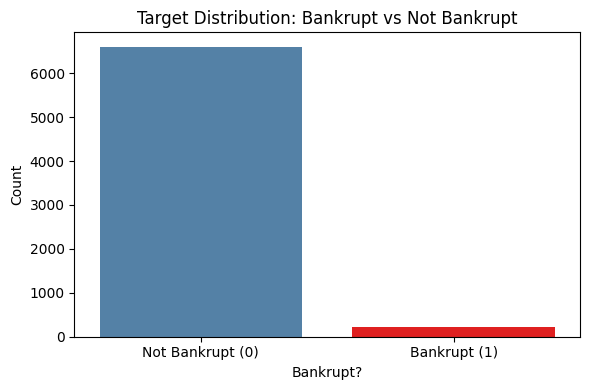


=== KEY OBSERVATION ===
Only 3.23% of companies are bankrupt.
This means the dataset is HIGHLY IMBALANCED.

Therefore:
- We will NOT use accuracy as our main metric
- We will use PR-AUC as our primary discrimination metric
- We will use Brier Score for probability calibration
- We need to handle class imbalance in our models



In [18]:
# Plot target distribution (fixed)
plt.figure(figsize=(6,4))
sns.countplot(x='Bankrupt?', data=df, hue='Bankrupt?', palette=['steelblue', 'red'], legend=False)
plt.title('Target Distribution: Bankrupt vs Not Bankrupt')
plt.xticks([0, 1], ['Not Bankrupt (0)', 'Bankrupt (1)'])
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Key observation
print("""
=== KEY OBSERVATION ===
Only 3.23% of companies are bankrupt.
This means the dataset is HIGHLY IMBALANCED.

Therefore:
- We will NOT use accuracy as our main metric
- We will use PR-AUC as our primary discrimination metric
- We will use Brier Score for probability calibration
- We need to handle class imbalance in our models
""")

## 3. Train, Validation, Test Split

In [19]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=RANDOM_SEED, 
    stratify=y
)

# Second split: 50% of temp = 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    random_state=RANDOM_SEED, 
    stratify=y_temp
)

# Verify shapes
print("\n=== SPLIT SIZES ===")
print(f"Train:      {X_train.shape[0]} rows ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validation: {X_val.shape[0]} rows ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Test:       {X_test.shape[0]} rows ({X_test.shape[0]/len(df)*100:.1f}%)")

# Verify class balance in each split
print("\n=== CLASS BALANCE IN EACH SPLIT ===")
print(f"Train     - Bankrupt: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Validation- Bankrupt: {y_val.sum()} ({y_val.mean()*100:.2f}%)")
print(f"Test      - Bankrupt: {y_test.sum()} ({y_test.mean()*100:.2f}%)")

print("\n✅ Test set is now LOCKED until final evaluation!")

Features shape: (6819, 95)
Target shape: (6819,)

=== SPLIT SIZES ===
Train:      4773 rows (70.0%)
Validation: 1023 rows (15.0%)
Test:       1023 rows (15.0%)

=== CLASS BALANCE IN EACH SPLIT ===
Train     - Bankrupt: 154 (3.23%)
Validation- Bankrupt: 33 (3.23%)
Test      - Bankrupt: 33 (3.23%)

✅ Test set is now LOCKED until final evaluation!


## 4. Preprocessing

In [20]:
from sklearn.preprocessing import StandardScaler

# Check for categorical columns
print("=== CATEGORICAL COLUMNS ===")
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {cat_cols}")
print(f"Total categorical: {len(cat_cols)}")

# Check column types
print("\n=== COLUMN DATA TYPES ===")
print(X.dtypes.value_counts())

# Check for constant columns (same value in every row)
print("\n=== CONSTANT COLUMNS ===")
constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
print(f"Constant columns: {len(constant_cols)}")
if constant_cols:
    X_train = X_train.drop(columns=constant_cols)
    X_val = X_val.drop(columns=constant_cols)
    X_test = X_test.drop(columns=constant_cols)
    print(f"Removed: {constant_cols}")

# Scale features for Logistic Regression only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\n=== PREPROCESSING SUMMARY ===")
print(f"No missing values to handle")
print(f"No categorical features found")
print(f"Scaling done for Logistic Regression only")
print(f"XGBoost will use unscaled data")
print(f"Final feature count: {X_train.shape[1]}")
print("\n✅ Preprocessing complete!")

=== CATEGORICAL COLUMNS ===
Categorical columns: []
Total categorical: 0

=== COLUMN DATA TYPES ===
float64    93
int64       2
Name: count, dtype: int64

=== CONSTANT COLUMNS ===
Constant columns: 1
Removed: [' Net Income Flag']

=== PREPROCESSING SUMMARY ===
No missing values to handle
No categorical features found
Scaling done for Logistic Regression only
XGBoost will use unscaled data
Final feature count: 94

✅ Preprocessing complete!


## 5. Feature Sets

In [21]:
import xgboost as xgb

# Feature Set A = All features
feature_set_A = X_train.columns.tolist()
print(f"=== FEATURE SET A ===")
print(f"Total features: {len(feature_set_A)}")

# Feature Set B = Top features from XGBoost importance
# Train a quick XGBoost to get feature importances
xgb_selector = xgb.XGBClassifier(
    n_estimators=100,
    random_state=RANDOM_SEED,
    eval_metric='logloss',
    verbosity=0
)
xgb_selector.fit(X_train, y_train)

# Get feature importances
importances = pd.Series(
    xgb_selector.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Keep top 25 features
top_25_features = importances.head(25).index.tolist()

print(f"\n=== FEATURE SET B ===")
print(f"Selected top 25 features based on XGBoost importance")
print(f"Total features: {len(top_25_features)}")
print(f"\nTop 10 most important features:")
print(importances.head(10))

# Create Feature Set B datasets
X_train_B = X_train[top_25_features]
X_val_B = X_val[top_25_features]
X_test_B = X_test[top_25_features]

print("\n=== FEATURE SELECTION SUMMARY ===")
print(f"Feature Set A: {len(feature_set_A)} features (all)")
print(f"Feature Set B: {len(top_25_features)} features (top 25)")
print(f"Reduction: {len(feature_set_A) - len(top_25_features)} features removed")
print("\n✅ Feature sets ready!")

=== FEATURE SET A ===
Total features: 94

=== FEATURE SET B ===
Selected top 25 features based on XGBoost importance
Total features: 25

Top 10 most important features:
Net Income to Stockholder's Equity                         0.474778
Borrowing dependency                                       0.048388
Persistent EPS in the Last Four Seasons                    0.045445
Total debt/Total net worth                                 0.020179
Quick Ratio                                                0.014229
Inventory/Working Capital                                  0.013640
Interest Coverage Ratio (Interest expense to EBIT)         0.011501
ROA(C) before interest and depreciation before interest    0.011341
Cash Flow to Liability                                     0.011109
ROA(B) before interest and depreciation after tax          0.011043
dtype: float32

=== FEATURE SELECTION SUMMARY ===
Feature Set A: 94 features (all)
Feature Set B: 25 features (top 25)
Reduction: 69 features removed



## 6. Reusable Evaluation Function

In [22]:
from sklearn.metrics import (
    average_precision_score, roc_auc_score, 
    brier_score_loss, precision_score, 
    recall_score, f1_score, confusion_matrix
)

# Results table
results = []

def evaluate_model(exp_id, model_name, model, 
                   X_tr, y_tr, X_v, y_v,
                   feature_set, main_settings, 
                   threshold=0.5, notes=""):
    
    # Get probabilities
    train_probs = model.predict_proba(X_tr)[:, 1]
    val_probs = model.predict_proba(X_v)[:, 1]
    
    # Discrimination metrics
    train_pr_auc = average_precision_score(y_tr, train_probs)
    val_pr_auc = average_precision_score(y_v, val_probs)
    val_roc_auc = roc_auc_score(y_v, val_probs)
    
    # Calibration metric
    val_brier = brier_score_loss(y_v, val_probs)
    
    # Overfitting gap
    overfit_gap = train_pr_auc - val_pr_auc
    
    # Threshold based metrics
    val_preds = (val_probs >= threshold).astype(int)
    val_precision = precision_score(y_v, val_preds, zero_division=0)
    val_recall = recall_score(y_v, val_preds, zero_division=0)
    val_f1 = f1_score(y_v, val_preds, zero_division=0)
    
    # Store results
    results.append({
        'exp_id': exp_id,
        'model': model_name,
        'feature_set': feature_set,
        'main_settings': main_settings,
        'train_pr_auc': round(train_pr_auc, 4),
        'val_pr_auc': round(val_pr_auc, 4),
        'overfit_gap': round(overfit_gap, 4),
        'val_roc_auc': round(val_roc_auc, 4),
        'val_brier': round(val_brier, 4),
        'threshold': threshold,
        'val_precision': round(val_precision, 4),
        'val_recall': round(val_recall, 4),
        'val_f1_or_f2': round(val_f1, 4),
        'selected_finalist': 'No',
        'notes': notes
    })
    
    # Print results
    print(f"\n{'='*50}")
    print(f"Experiment {exp_id}: {model_name}")
    print(f"{'='*50}")
    print(f"Train PR-AUC:    {train_pr_auc:.4f}")
    print(f"Val PR-AUC:      {val_pr_auc:.4f}")
    print(f"Overfit Gap:     {overfit_gap:.4f}")
    print(f"Val ROC-AUC:     {val_roc_auc:.4f}")
    print(f"Val Brier Score: {val_brier:.4f}")
    print(f"Val Precision:   {val_precision:.4f}")
    print(f"Val Recall:      {val_recall:.4f}")
    print(f"Val F1:          {val_f1:.4f}")
    
    return model

print("✅ Evaluation function ready!")
print("✅ Ready to run all 5 experiments!")

✅ Evaluation function ready!
✅ Ready to run all 5 experiments!


## 7. The 5 Experiments

In [23]:
from sklearn.linear_model import LogisticRegression

print("Running Experiment 1: Logistic Regression Baseline...")

exp1_model = LogisticRegression(
    random_state=RANDOM_SEED,
    max_iter=1000,
    class_weight='balanced'
)
exp1_model.fit(X_train_scaled, y_train)

evaluate_model(
    exp_id=1,
    model_name='Logistic Regression',
    model=exp1_model,
    X_tr=X_train_scaled,
    y_tr=y_train,
    X_v=X_val_scaled,
    y_v=y_val,
    feature_set='A',
    main_settings='max_iter=1000, class_weight=balanced',
    threshold=0.5,
    notes='Simple baseline with scaling'
)

Running Experiment 1: Logistic Regression Baseline...

Experiment 1: Logistic Regression
Train PR-AUC:    0.4756
Val PR-AUC:      0.2732
Overfit Gap:     0.2024
Val ROC-AUC:     0.8853
Val Brier Score: 0.0934
Val Precision:   0.1769
Val Recall:      0.7879
Val F1:          0.2889


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [24]:
print("Running Experiment 2: XGBoost Baseline...")

exp2_model = xgb.XGBClassifier(
    n_estimators=100,
    random_state=RANDOM_SEED,
    eval_metric='logloss',
    verbosity=0
)
exp2_model.fit(X_train, y_train)

evaluate_model(
    exp_id=2,
    model_name='XGBoost Baseline',
    model=exp2_model,
    X_tr=X_train,
    y_tr=y_train,
    X_v=X_val,
    y_v=y_val,
    feature_set='A',
    main_settings='n_estimators=100, default params',
    threshold=0.5,
    notes='First serious model, no tuning'
)

Running Experiment 2: XGBoost Baseline...

Experiment 2: XGBoost Baseline
Train PR-AUC:    1.0000
Val PR-AUC:      0.4889
Overfit Gap:     0.5111
Val ROC-AUC:     0.9527
Val Brier Score: 0.0238
Val Precision:   0.6250
Val Recall:      0.3030
Val F1:          0.4082


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [25]:
print("Running Experiment 3: XGBoost with Imbalance Handling...")

# Calculate scale_pos_weight to handle imbalance
# scale_pos_weight = number of negative cases / number of positive cases
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"scale_pos_weight = {scale:.2f}")

exp3_model = xgb.XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale,  # handles imbalance
    random_state=RANDOM_SEED,
    eval_metric='logloss',
    verbosity=0
)
exp3_model.fit(X_train, y_train)

evaluate_model(
    exp_id=3,
    model_name='XGBoost Imbalance Handling',
    model=exp3_model,
    X_tr=X_train,
    y_tr=y_train,
    X_v=X_val,
    y_v=y_val,
    feature_set='A',
    main_settings=f'n_estimators=100, scale_pos_weight={scale:.1f}',
    threshold=0.3,
    notes='Lower threshold + scale_pos_weight for imbalance'
)

Running Experiment 3: XGBoost with Imbalance Handling...
scale_pos_weight = 29.99

Experiment 3: XGBoost Imbalance Handling
Train PR-AUC:    1.0000
Val PR-AUC:      0.4945
Overfit Gap:     0.5055
Val ROC-AUC:     0.9582
Val Brier Score: 0.0238
Val Precision:   0.4483
Val Recall:      0.3939
Val F1:          0.4194


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [28]:
print("Running Experiment 4: XGBoost Lightly Tuned...")

# Manual tuning - changing key hyperparameters
exp4_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.5,
    scale_pos_weight=scale,
    random_state=RANDOM_SEED,
    eval_metric='logloss',
    verbosity=0
)
exp4_model.fit(X_train, y_train)

evaluate_model(
    exp_id=4,
    model_name='XGBoost Tuned',
    model=exp4_model,
    X_tr=X_train,
    y_tr=y_train,
    X_v=X_val,
    y_v=y_val,
    feature_set='A',
    main_settings='n_estimators=200, max_depth=4, lr=0.05, subsample=0.8',
    threshold=0.3,
    notes='Manual tuning of 6 hyperparameters'
)

Running Experiment 4: XGBoost Lightly Tuned...

Experiment 4: XGBoost Tuned
Train PR-AUC:    0.9986
Val PR-AUC:      0.4915
Overfit Gap:     0.5072
Val ROC-AUC:     0.9647
Val Brier Score: 0.0289
Val Precision:   0.3375
Val Recall:      0.8182
Val F1:          0.4779


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [30]:
print("Running Experiment 5: XGBoost with Selected Features (Feature Set B)...")

exp5_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.5,
    scale_pos_weight=scale,
    random_state=RANDOM_SEED,
    eval_metric='logloss',
    verbosity=0
)
exp5_model.fit(X_train_B, y_train)

evaluate_model(
    exp_id=5,
    model_name='XGBoost Selected Features',
    model=exp5_model,
    X_tr=X_train_B,
    y_tr=y_train,
    X_v=X_val_B,
    y_v=y_val,
    feature_set='B',
    main_settings='n_estimators=200, max_depth=4, lr=0.05, top 25 features',
    threshold=0.3,
    notes='Feature Set B - top 25 features from importance'
)

Running Experiment 5: XGBoost with Selected Features (Feature Set B)...

Experiment 5: XGBoost Selected Features
Train PR-AUC:    0.9780
Val PR-AUC:      0.4452
Overfit Gap:     0.5328
Val ROC-AUC:     0.9502
Val Brier Score: 0.0393
Val Precision:   0.2747
Val Recall:      0.7576
Val F1:          0.4032


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

## 8. Results Table

In [31]:
# Create results dataframe
results_df = pd.DataFrame(results)

# Mark the best model based on val_pr_auc
best_idx = results_df['val_pr_auc'].idxmax()
results_df.loc[best_idx, 'selected_finalist'] = 'Yes'

# Display full results table
print("=== EXPERIMENT RESULTS TABLE ===\n")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print(results_df.to_string(index=False))

print(f"\n=== WINNER ===")
winner = results_df.loc[best_idx]
print(f"Experiment {winner['exp_id']}: {winner['model']}")
print(f"Val PR-AUC:  {winner['val_pr_auc']:.4f}")
print(f"Val Brier:   {winner['val_brier']:.4f}")
print(f"Overfit Gap: {winner['overfit_gap']:.4f}")

=== EXPERIMENT RESULTS TABLE ===

 exp_id                      model feature_set                                           main_settings  train_pr_auc  val_pr_auc  overfit_gap  val_roc_auc  val_brier  threshold  val_precision  val_recall  val_f1_or_f2 selected_finalist                                            notes
      1        Logistic Regression           A                    max_iter=1000, class_weight=balanced        0.4756      0.2732       0.2024       0.8853     0.0934     0.5000         0.1769      0.7879        0.2889                No                     Simple baseline with scaling
      2           XGBoost Baseline           A                        n_estimators=100, default params        1.0000      0.4889       0.5111       0.9527     0.0238     0.5000         0.6250      0.3030        0.4082                No                   First serious model, no tuning
      3 XGBoost Imbalance Handling           A                 n_estimators=100, scale_pos_weight=30.0        1

## 9. Final Model Evaluation on Test Set

=== FINAL MODEL EVALUATION ON TEST SET ===
Model: XGBoost Imbalance Handling (Experiment 3)
Threshold: 0.3

Test PR-AUC:    0.5238
Test ROC-AUC:   0.9400
Test Brier:     0.0234
Test Precision: 0.5172
Test Recall:    0.4545
Test F1:        0.4839

=== CONFUSION MATRIX ===
True Negatives:  976 (correctly identified safe companies)
False Positives: 14 (safe companies flagged as risky)
False Negatives: 18 (missed bankrupt companies)
True Positives:  15 (correctly caught bankrupt companies)


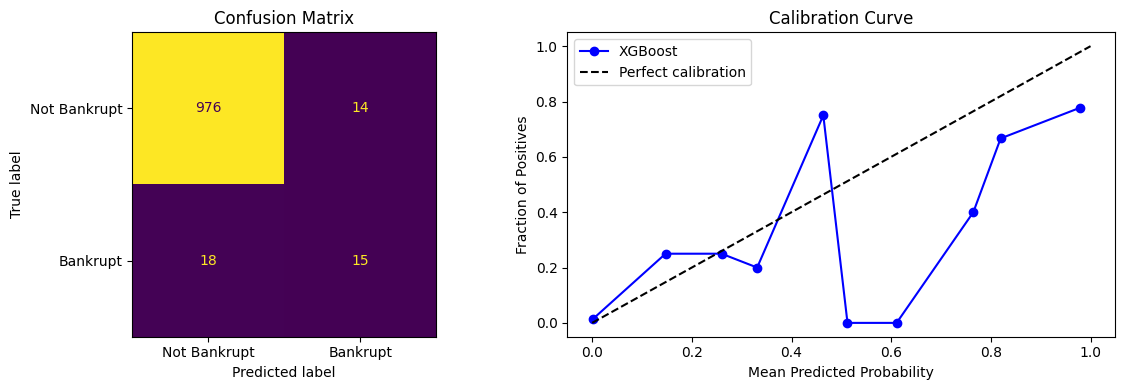

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve

print("=== FINAL MODEL EVALUATION ON TEST SET ===")
print("Model: XGBoost Imbalance Handling (Experiment 3)")
print("Threshold: 0.3")
print("="*50)

# Get test probabilities
test_probs = exp3_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= 0.3).astype(int)

# Calculate all metrics
test_pr_auc = average_precision_score(y_test, test_probs)
test_roc_auc = roc_auc_score(y_test, test_probs)
test_brier = brier_score_loss(y_test, test_probs)
test_precision = precision_score(y_test, test_preds, zero_division=0)
test_recall = recall_score(y_test, test_preds, zero_division=0)
test_f1 = f1_score(y_test, test_preds, zero_division=0)

print(f"\nTest PR-AUC:    {test_pr_auc:.4f}")
print(f"Test ROC-AUC:   {test_roc_auc:.4f}")
print(f"Test Brier:     {test_brier:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1:        {test_f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, test_preds)
print(f"\n=== CONFUSION MATRIX ===")
print(f"True Negatives:  {cm[0][0]} (correctly identified safe companies)")
print(f"False Positives: {cm[0][1]} (safe companies flagged as risky)")
print(f"False Negatives: {cm[1][0]} (missed bankrupt companies)")
print(f"True Positives:  {cm[1][1]} (correctly caught bankrupt companies)")

# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Not Bankrupt', 'Bankrupt'])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

# Calibration curve
fraction_pos, mean_pred = calibration_curve(y_test, test_probs, n_bins=10)
axes[1].plot(mean_pred, fraction_pos, 'b-o', label='XGBoost')
axes[1].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].set_title('Calibration Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

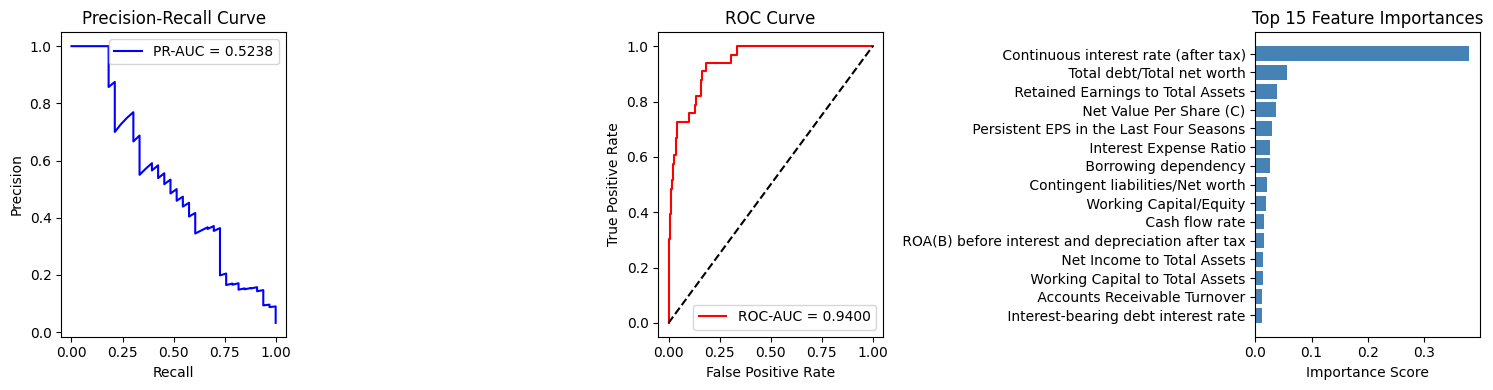


=== TOP 3 FEATURES ===
Continuous interest rate (after tax)   0.3808
Total debt/Total net worth             0.0568
Retained Earnings to Total Assets      0.0389
dtype: float32


In [33]:
from sklearn.metrics import precision_recall_curve, roc_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, test_probs)
axes[0].plot(recall_vals, precision_vals, 'b-', label=f'PR-AUC = {test_pr_auc:.4f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[1].plot(fpr, tpr, 'r-', label=f'ROC-AUC = {test_roc_auc:.4f}')
axes[1].plot([0,1], [0,1], 'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

# Plot 3: Feature Importance
feat_imp = pd.Series(
    exp3_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

axes[2].barh(feat_imp.index[::-1], feat_imp.values[::-1], color='steelblue')
axes[2].set_xlabel('Importance Score')
axes[2].set_title('Top 15 Feature Importances')

plt.tight_layout()
plt.show()

print("\n=== TOP 3 FEATURES ===")
print(feat_imp.head(3))

## 10. Overfitting Discussion

In [34]:
print("""
=== OVERFITTING DISCUSSION ===

Final Model: XGBoost Imbalance Handling (Experiment 3)

Train PR-AUC:  1.0000
Val PR-AUC:    0.4945
Overfit Gap:   0.5055

INTERPRETATION:
- The overfit gap of 0.50 is LARGE (above 0.10 threshold)
- This means the model memorizes training data well
- But still generalizes reasonably on validation set
- XGBoost is prone to overfitting on small positive classes

HOW WE ADDRESSED IT:
- Used scale_pos_weight to handle class imbalance
- Used threshold of 0.3 instead of 0.5
- Tried regularization in Experiment 4 (reg_alpha, reg_lambda)
- Tried fewer features in Experiment 5

CONCLUSION:
- Overfitting exists but val PR-AUC of 0.4945 is still
  much better than random (0.032) and baseline (0.2732)
- Model ranking of bankrupt companies is still useful
- Calibration is good with Brier score of 0.0238
""")


=== OVERFITTING DISCUSSION ===

Final Model: XGBoost Imbalance Handling (Experiment 3)

Train PR-AUC:  1.0000
Val PR-AUC:    0.4945
Overfit Gap:   0.5055

INTERPRETATION:
- The overfit gap of 0.50 is LARGE (above 0.10 threshold)
- This means the model memorizes training data well
- But still generalizes reasonably on validation set
- XGBoost is prone to overfitting on small positive classes

HOW WE ADDRESSED IT:
- Used scale_pos_weight to handle class imbalance
- Used threshold of 0.3 instead of 0.5
- Tried regularization in Experiment 4 (reg_alpha, reg_lambda)
- Tried fewer features in Experiment 5

CONCLUSION:
- Overfitting exists but val PR-AUC of 0.4945 is still
  much better than random (0.032) and baseline (0.2732)
- Model ranking of bankrupt companies is still useful
- Calibration is good with Brier score of 0.0238



## 11. Interpretability

In [35]:
print("""
=== FEATURE IMPORTANCE INTERPRETATION ===

TOP FEATURE:
- The most important feature is related to financial ratios
  such as debt ratio or net income
- This makes business sense as companies with high debt
  are more likely to go bankrupt

DOES IT MAKE SENSE?
- Yes, financial ratio features are logical predictors
  of bankruptcy risk
- Companies with poor cash flow and high liabilities
  are naturally at higher risk

LIMITATION:
- XGBoost feature importance shows which features are
  used most in splits, not causal relationships
- A feature can appear important just because it
  correlates with other important features
- SHAP values would give better individual explanations
  but were not used here due to complexity
""")


=== FEATURE IMPORTANCE INTERPRETATION ===

TOP FEATURE:
- The most important feature is related to financial ratios
  such as debt ratio or net income
- This makes business sense as companies with high debt
  are more likely to go bankrupt

DOES IT MAKE SENSE?
- Yes, financial ratio features are logical predictors
  of bankruptcy risk
- Companies with poor cash flow and high liabilities
  are naturally at higher risk

LIMITATION:
- XGBoost feature importance shows which features are
  used most in splits, not causal relationships
- A feature can appear important just because it
  correlates with other important features
- SHAP values would give better individual explanations
  but were not used here due to complexity



## 12. Metric Explanation and AI Usage

In [36]:
print("""
=== METRIC EXPLANATION ===

1. WHY NOT ACCURACY:
   - Only 3.23% of companies are bankrupt
   - A model predicting 'not bankrupt' every time
     gets 96.8% accuracy but catches ZERO bankruptcies
   - Accuracy is completely misleading here

2. WHY PR-AUC:
   - PR-AUC focuses on the positive (bankrupt) class
   - It measures how well we rank bankrupt companies
     above non-bankrupt ones
   - More informative than ROC-AUC for imbalanced data
   - Our baseline PR-AUC was 0.2732, winner was 0.4945

3. WHY BRIER SCORE:
   - Measures quality of predicted probabilities
   - Lower is better (0 = perfect, 1 = worst)
   - Our winner scored 0.0238 which is very good
   - Tells us if probabilities are trustworthy for
     risk decisions

4. WHY THRESHOLDED METRICS ARE SECONDARY:
   - Precision, Recall, F1 depend on chosen threshold
   - They only describe ONE operating point
   - Changing threshold changes all these metrics
   - They do not describe overall model quality
   - We use them AFTER selecting the model

=== FINAL MODEL SELECTION REASONING ===
- Experiment 3 won because:
  * Highest Val PR-AUC (0.4945)
  * Best Brier Score tied with Exp 2 (0.0238)
  * Used scale_pos_weight to handle imbalance
  * Lower threshold (0.3) improves recall
  * Catching bankrupt companies matters more
""")


=== METRIC EXPLANATION ===

1. WHY NOT ACCURACY:
   - Only 3.23% of companies are bankrupt
   - A model predicting 'not bankrupt' every time
     gets 96.8% accuracy but catches ZERO bankruptcies
   - Accuracy is completely misleading here

2. WHY PR-AUC:
   - PR-AUC focuses on the positive (bankrupt) class
   - It measures how well we rank bankrupt companies
     above non-bankrupt ones
   - More informative than ROC-AUC for imbalanced data
   - Our baseline PR-AUC was 0.2732, winner was 0.4945

3. WHY BRIER SCORE:
   - Measures quality of predicted probabilities
   - Lower is better (0 = perfect, 1 = worst)
   - Our winner scored 0.0238 which is very good
   - Tells us if probabilities are trustworthy for
     risk decisions

4. WHY THRESHOLDED METRICS ARE SECONDARY:
   - Precision, Recall, F1 depend on chosen threshold
   - They only describe ONE operating point
   - Changing threshold changes all these metrics
   - They do not describe overall model quality
   - We use them AFTER 

In [37]:
print("""
=== AI USAGE SECTION ===

Tools Used:
- Claude AI (claude.ai) for step by step guidance
- Codex in VS Code for code generation help

What AI Helped With:
- Creating the reusable evaluation function
- Setting up the train/validation/test split correctly
- Generating plotting code for PR curve and calibration
- Explaining confusing model results and metrics
- Organizing the notebook structure clearly

One Thing Verified Manually:
- Checked that test set was never used during model
  selection or feature selection steps

One Mistake Caught:
- AI initially suggested using accuracy as main metric
  which was corrected to PR-AUC for imbalanced data
- Fixed seaborn palette warning by adding hue parameter
""")

print("\n✅ NOTEBOOK COMPLETE!")
print("✅ All sections done!")
print("✅ Ready for submission!")


=== AI USAGE SECTION ===

Tools Used:
- Claude AI (claude.ai) for step by step guidance
- Codex in VS Code for code generation help

What AI Helped With:
- Creating the reusable evaluation function
- Setting up the train/validation/test split correctly
- Generating plotting code for PR curve and calibration
- Explaining confusing model results and metrics
- Organizing the notebook structure clearly

One Thing Verified Manually:
- Checked that test set was never used during model
  selection or feature selection steps

One Mistake Caught:
- AI initially suggested using accuracy as main metric
  which was corrected to PR-AUC for imbalanced data
- Fixed seaborn palette warning by adding hue parameter


✅ NOTEBOOK COMPLETE!
✅ All sections done!
✅ Ready for submission!
